In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

sns.set_theme(style="whitegrid")

df = pd.read_excel("WHR26_Data_Figure_2.1.xlsx")

print("Dataset Shape:", df.shape)
df.head()

df = df.rename(columns={
    "Country name": "Country",
    "Life evaluation (3-year average)": "Life_Evaluation",
    "Lower whisker": "Lower_Whisker",
    "Upper whisker": "Upper_Whisker",
    "Explained by: Log GDP per capita": "GDP_per_Capita",
    "Explained by: Social support": "Social_Support",
    "Explained by: Healthy life expectancy": "Healthy_Life_Expectancy",
    "Explained by: Freedom to make life choices": "Freedom",
    "Explained by: Generosity": "Generosity",
    "Explained by: Perceptions of corruption": "Corruption",
    "Dystopia + residual": "Dystopia_Residual"
})

df.head()

factors = [
    "GDP_per_Capita",
    "Social_Support",
    "Healthy_Life_Expectancy",
    "Freedom",
    "Generosity",
    "Corruption"
]

df_factor = df.dropna(
    subset=["Life_Evaluation"] + factors
).copy()

print("Original dataset:", df.shape)
print("Complete factor dataset:", df_factor.shape)

Dataset Shape: (2116, 13)
Original dataset: (2116, 13)
Complete factor dataset: (1013, 13)


In [2]:
fig = px.choropleth(
    df,
    locations="Country",
    locationmode="country names",
    color="Life_Evaluation",
    hover_name="Country",
    hover_data={
        "Year": True,
        "Life_Evaluation": ":.2f"
    },
    color_continuous_scale="RdYlGn",
    title="Global Distribution of Life Evaluation"
)

fig.update_layout(
    title_x=0.5,
    template="plotly_white"
)

fig.show()

/usr/local/lib/python3.12/dist-packages/kaleido/_sync_server.py:11: UserWarning:




This means that static image generation (e.g. `fig.write_image()`) will not work.

Please upgrade Plotly to version 6.1.1 or greater, or downgrade Kaleido to version 0.2.1.

You can however, use the Kaleido API directly which will work with your plotly version. `kaleido.write_fig(...)`, for example. Please see the kaleido documentation.




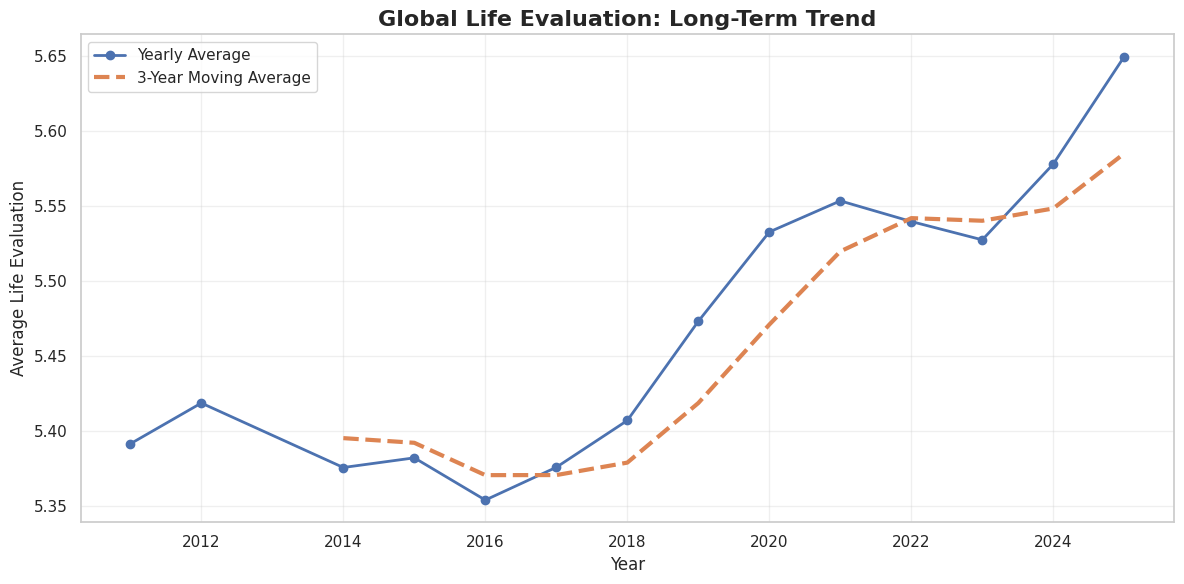

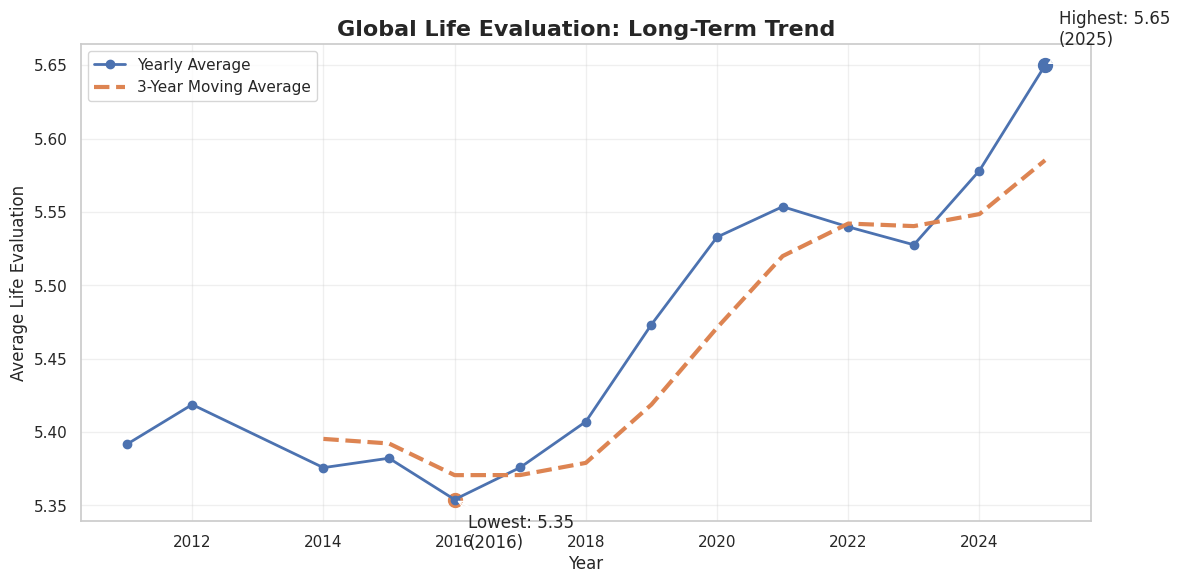

In [3]:
# Calculate yearly average life evaluation
yearly_happiness = (
    df.groupby("Year")["Life_Evaluation"]
    .mean()
    .reset_index()
)

# Calculate 3-year moving average
yearly_happiness["3Y_Moving_Average"] = (
    yearly_happiness["Life_Evaluation"]
    .rolling(window=3)
    .mean()
)

plt.figure(figsize=(12, 6))

# Actual yearly values
plt.plot(
    yearly_happiness["Year"],
    yearly_happiness["Life_Evaluation"],
    marker="o",
    linewidth=2,
    label="Yearly Average"
)

# Moving average
plt.plot(
    yearly_happiness["Year"],
    yearly_happiness["3Y_Moving_Average"],
    linestyle="--",
    linewidth=3,
    label="3-Year Moving Average"
)

plt.title(
    "Global Life Evaluation: Long-Term Trend",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Year")
plt.ylabel("Average Life Evaluation")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


# Identify highest and lowest yearly averages
highest = yearly_happiness.loc[
    yearly_happiness["Life_Evaluation"].idxmax()
]

lowest = yearly_happiness.loc[
    yearly_happiness["Life_Evaluation"].idxmin()
]

plt.figure(figsize=(12, 6))

plt.plot(
    yearly_happiness["Year"],
    yearly_happiness["Life_Evaluation"],
    marker="o",
    linewidth=2,
    label="Yearly Average"
)

plt.plot(
    yearly_happiness["Year"],
    yearly_happiness["3Y_Moving_Average"],
    linestyle="--",
    linewidth=3,
    label="3-Year Moving Average"
)

# Highlight highest point
plt.scatter(
    highest["Year"],
    highest["Life_Evaluation"],
    s=100
)

plt.annotate(
    f"Highest: {highest['Life_Evaluation']:.2f}\n"
    f"({int(highest['Year'])})",
    xy=(highest["Year"], highest["Life_Evaluation"]),
    xytext=(10, 15),
    textcoords="offset points",
    arrowprops=dict(arrowstyle="->")
)

# Highlight lowest point
plt.scatter(
    lowest["Year"],
    lowest["Life_Evaluation"],
    s=100
)

plt.annotate(
    f"Lowest: {lowest['Life_Evaluation']:.2f}\n"
    f"({int(lowest['Year'])})",
    xy=(lowest["Year"], lowest["Life_Evaluation"]),
    xytext=(10, -35),
    textcoords="offset points",
    arrowprops=dict(arrowstyle="->")
)

plt.title(
    "Global Life Evaluation: Long-Term Trend",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Year")
plt.ylabel("Average Life Evaluation")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


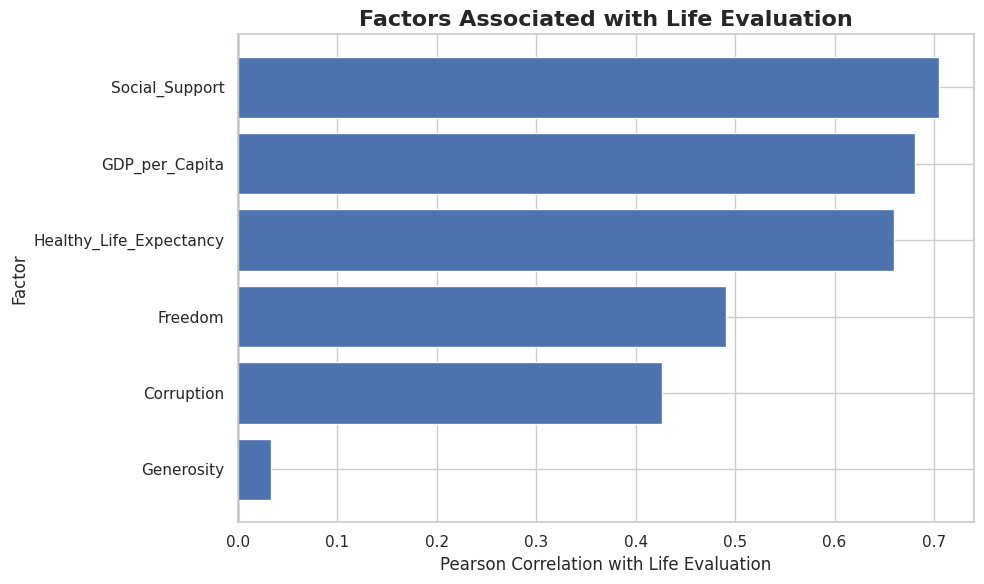

In [4]:
correlations = (
    df_factor[
        [
            "Life_Evaluation",
            "GDP_per_Capita",
            "Social_Support",
            "Healthy_Life_Expectancy",
            "Freedom",
            "Generosity",
            "Corruption"
        ]
    ]
    .corr()["Life_Evaluation"]
    .drop("Life_Evaluation")
    .sort_values()
)

plt.figure(figsize=(10, 6))

plt.barh(
    correlations.index,
    correlations.values
)

plt.axvline(
    0,
    linewidth=1
)

plt.title(
    "Factors Associated with Life Evaluation",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Pearson Correlation with Life Evaluation")
plt.ylabel("Factor")

plt.tight_layout()
plt.show()

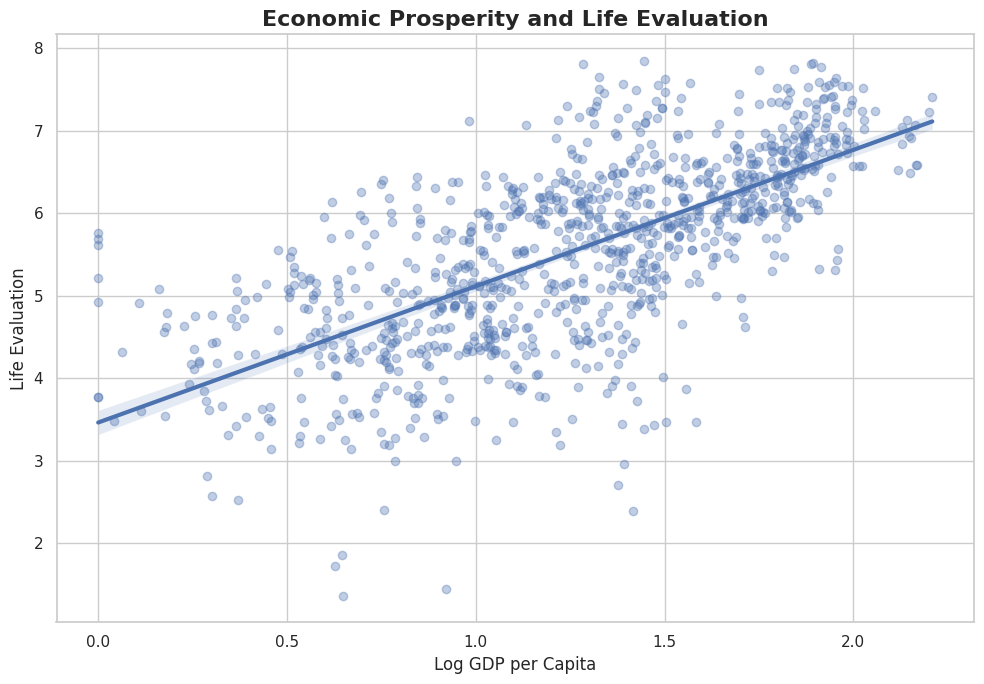

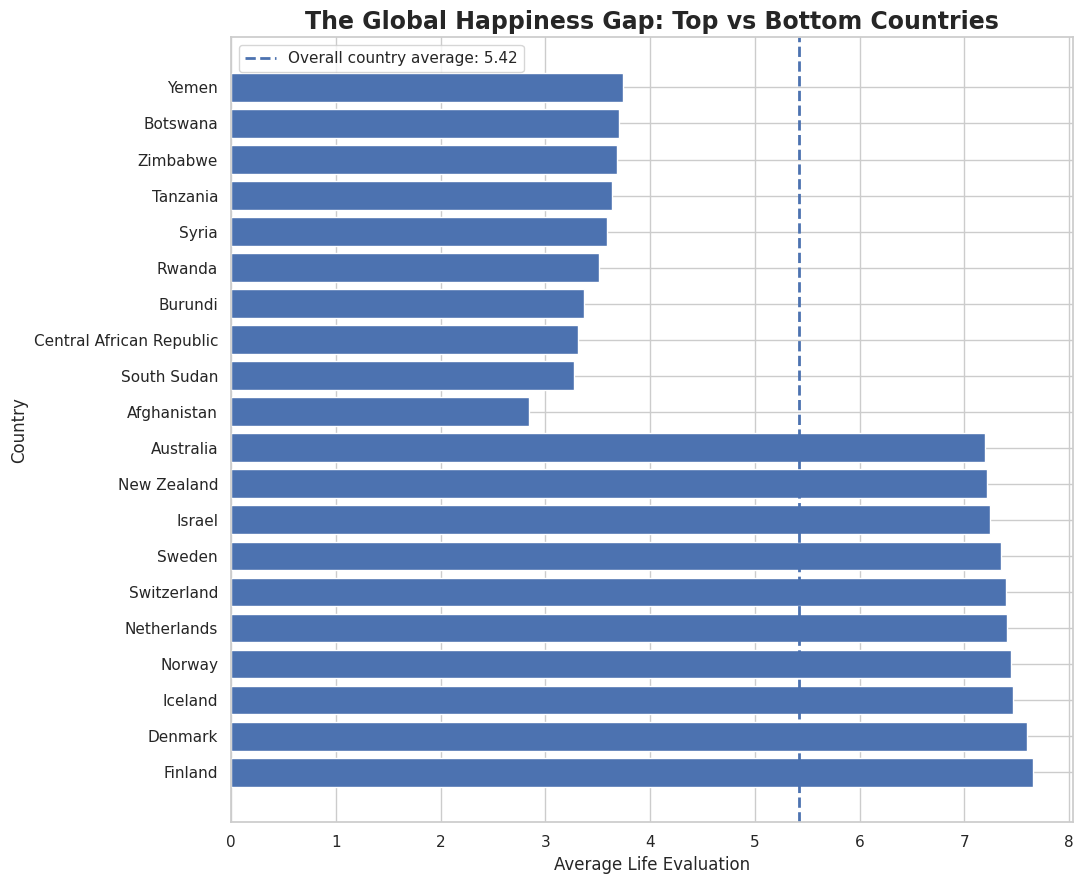

In [5]:
plt.figure(figsize=(10, 7))

sns.regplot(
    data=df_factor,
    x="GDP_per_Capita",
    y="Life_Evaluation",
    scatter_kws={"alpha": 0.35},
    line_kws={"linewidth": 3}
)

plt.title(
    "Economic Prosperity and Life Evaluation",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Log GDP per Capita")
plt.ylabel("Life Evaluation")

plt.tight_layout()
plt.show()

# Calculate average life evaluation by country
country_happiness = (
    df.groupby("Country")["Life_Evaluation"]
    .mean()
    .sort_values(ascending=False)
)

# Select top and bottom 10
top10 = country_happiness.head(10)
bottom10 = country_happiness.tail(10).sort_values()

# Combine them
comparison = pd.concat([
    top10,
    bottom10
])

plt.figure(figsize=(11, 9))

plt.barh(
    comparison.index,
    comparison.values
)

plt.axvline(
    country_happiness.mean(),
    linestyle="--",
    linewidth=2,
    label=f"Overall country average: {country_happiness.mean():.2f}"
)

plt.title(
    "The Global Happiness Gap: Top vs Bottom Countries",
    fontsize=17,
    fontweight="bold"
)

plt.xlabel("Average Life Evaluation")
plt.ylabel("Country")

plt.legend()

plt.tight_layout()
plt.show()

In [6]:
factor_cols = [
    "GDP_per_Capita",
    "Social_Support",
    "Healthy_Life_Expectancy",
    "Freedom",
    "Generosity",
    "Corruption"
]

# Top 10 countries
top10_names = top10.index

top10_data = df_factor[
    df_factor["Country"].isin(top10_names)
]

# Calculate averages
top10_factor_avg = top10_data[factor_cols].mean()

overall_factor_avg = df_factor[factor_cols].mean()

comparison_factors = pd.DataFrame({
    "Top 10 Countries": top10_factor_avg,
    "Overall Dataset": overall_factor_avg
})

print(comparison_factors)

                         Top 10 Countries  Overall Dataset
GDP_per_Capita                   1.752500         1.266128
Social_Support                   1.451739         1.094809
Healthy_Life_Expectancy          0.804700         0.553158
Freedom                          0.770411         0.609201
Generosity                       0.207436         0.147717
Corruption                       0.387621         0.144717


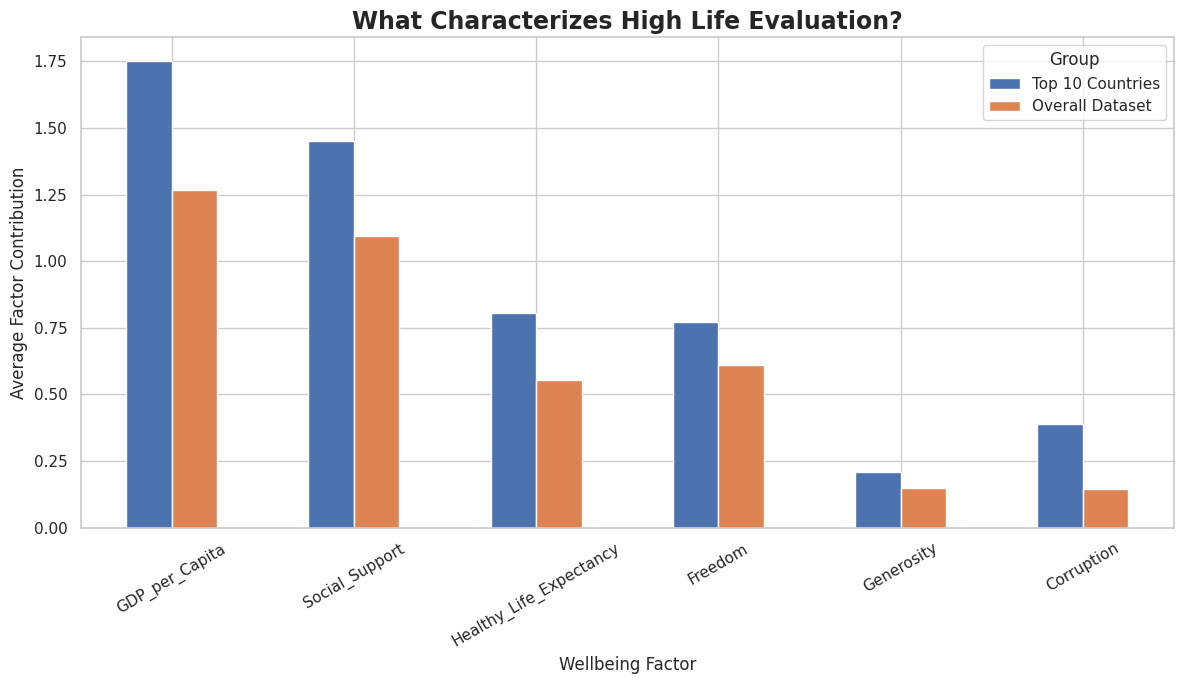

In [7]:
comparison_factors.plot(
    kind="bar",
    figsize=(12, 7)
)

plt.title(
    "What Characterizes High Life Evaluation?",
    fontsize=17,
    fontweight="bold"
)

plt.xlabel("Wellbeing Factor")
plt.ylabel("Average Factor Contribution")

plt.xticks(rotation=30)

plt.legend(
    title="Group"
)

plt.tight_layout()
plt.show()

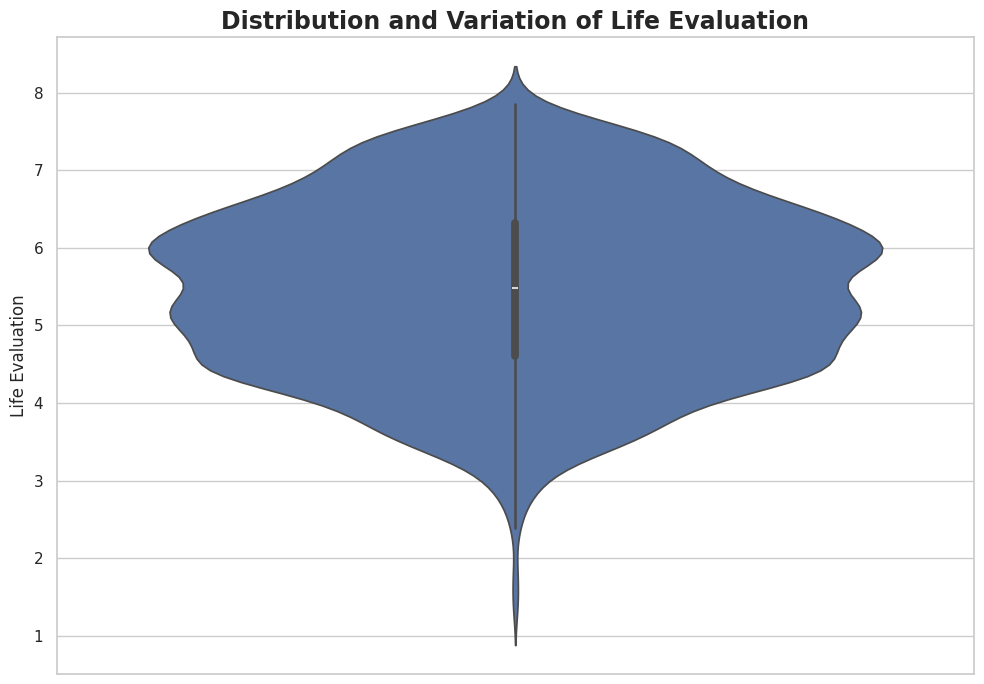

In [8]:
plt.figure(figsize=(10, 7))

sns.violinplot(
    data=df,
    y="Life_Evaluation",
    inner="box"
)

plt.title(
    "Distribution and Variation of Life Evaluation",
    fontsize=17,
    fontweight="bold"
)

plt.ylabel("Life Evaluation")

plt.tight_layout()
plt.show()

In [9]:
import os

os.makedirs("week2_visualizations", exist_ok=True)

# 1. Global happiness map
fig = px.choropleth(
    df,
    locations="Country",
    locationmode="country names",
    color="Life_Evaluation",
    hover_name="Country",
    hover_data=["Year", "Life_Evaluation"],
    color_continuous_scale="RdYlGn",
    title="Global Distribution of Life Evaluation"
)
fig.write_image("week2_visualizations/01_global_happiness_map.png", scale=2)

# 2. Trend
plt.figure(figsize=(12, 6))
plt.plot(
    yearly_happiness["Year"],
    yearly_happiness["Life_Evaluation"],
    marker="o",
    linewidth=2,
    label="Yearly Average"
)
plt.plot(
    yearly_happiness["Year"],
    yearly_happiness["3Y_Moving_Average"],
    linestyle="--",
    linewidth=3,
    label="3-Year Moving Average"
)
plt.title("Global Life Evaluation: Long-Term Trend")
plt.xlabel("Year")
plt.ylabel("Average Life Evaluation")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(
    "week2_visualizations/02_happiness_trend.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

# 3. Factor correlations
plt.figure(figsize=(10, 6))
plt.barh(correlations.index, correlations.values)
plt.axvline(0, linewidth=1)
plt.title("Factors Associated with Life Evaluation")
plt.xlabel("Pearson Correlation with Life Evaluation")
plt.ylabel("Factor")
plt.tight_layout()
plt.savefig(
    "week2_visualizations/03_factor_correlations.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

# 4. GDP relationship
plt.figure(figsize=(10, 7))
sns.regplot(
    data=df_factor,
    x="GDP_per_Capita",
    y="Life_Evaluation",
    scatter_kws={"alpha": 0.35},
    line_kws={"linewidth": 3}
)
plt.title("Economic Prosperity and Life Evaluation")
plt.xlabel("Log GDP per Capita")
plt.ylabel("Life Evaluation")
plt.tight_layout()
plt.savefig(
    "week2_visualizations/04_gdp_relationship.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

# 5. Top vs bottom
plt.figure(figsize=(11, 9))
plt.barh(comparison.index, comparison.values)
plt.axvline(
    country_happiness.mean(),
    linestyle="--",
    linewidth=2,
    label=f"Overall country average: {country_happiness.mean():.2f}"
)
plt.title("The Global Happiness Gap: Top vs Bottom Countries")
plt.xlabel("Average Life Evaluation")
plt.ylabel("Country")
plt.legend()
plt.tight_layout()
plt.savefig(
    "week2_visualizations/05_happiness_gap.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

# 6. High-happiness factor profile
ax = comparison_factors.plot(
    kind="bar",
    figsize=(12, 7)
)
plt.title("What Characterizes High Life Evaluation?")
plt.xlabel("Wellbeing Factor")
plt.ylabel("Average Factor Contribution")
plt.xticks(rotation=30)
plt.legend(title="Group")
plt.tight_layout()
plt.savefig(
    "week2_visualizations/06_high_happiness_profile.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

# 7. Violin plot
plt.figure(figsize=(10, 7))
sns.violinplot(
    data=df,
    y="Life_Evaluation",
    inner="box"
)
plt.title("Distribution and Variation of Life Evaluation")
plt.ylabel("Life Evaluation")
plt.tight_layout()
plt.savefig(
    "week2_visualizations/07_life_evaluation_distribution.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

print("All 7 visualizations saved successfully.")

ValueError: 
Image export using the "kaleido" engine requires the kaleido package,
which can be installed using pip:
    $ pip install -U kaleido


In [11]:
!pip install -U kaleido

In [10]:
!pip install -q kaleido

In [12]:
import kaleido
print("Kaleido is installed successfully")

Kaleido is installed successfully


In [13]:
fig.write_image(
    "week2_visualizations/01_global_happiness_map.png",
    scale=2
)

ValueError: 
Image export using the "kaleido" engine requires the kaleido package,
which can be installed using pip:
    $ pip install -U kaleido


In [14]:
!pip install -q geopandas

In [15]:
import geopandas as gpd
import matplotlib.pyplot as plt

print("GeoPandas version:", gpd.__version__)

GeoPandas version: 1.1.4


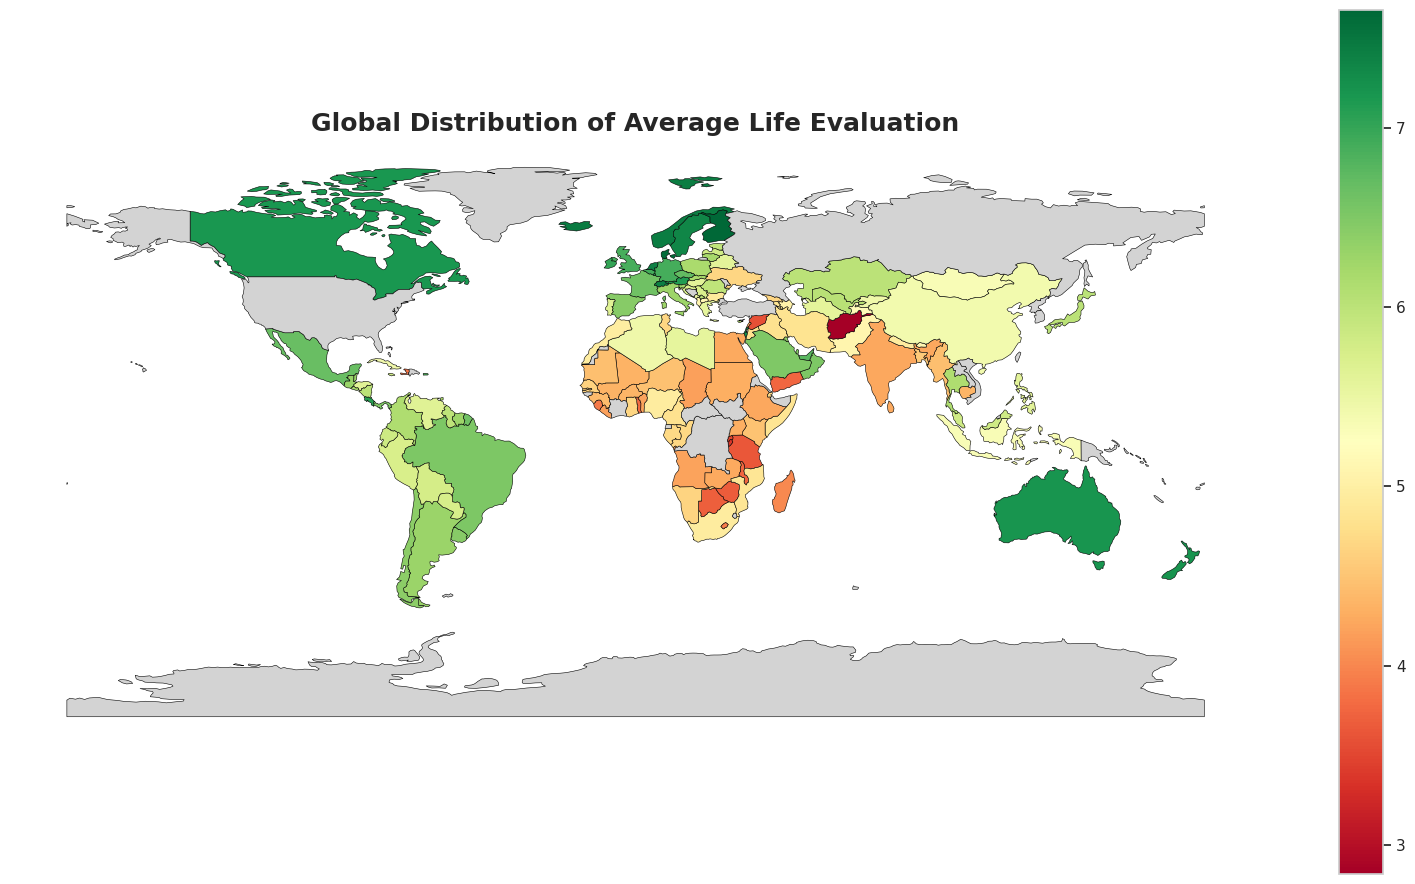

In [17]:
# Average life evaluation for each country
country_map_data = (
    df.groupby("Country")["Life_Evaluation"]
    .mean()
    .reset_index()
)

country_map_data.head()

# Load the world map
world = gpd.read_file(
    "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
)

# Match country names
world_data = world.merge(
    country_map_data,
    left_on="NAME",
    right_on="Country",
    how="left"
)

# Create map
fig, ax = plt.subplots(figsize=(16, 9))

world_data.plot(
    column="Life_Evaluation",
    cmap="RdYlGn",
    linewidth=0.4,
    edgecolor="black",
    legend=True,
    ax=ax,
    missing_kwds={
        "color": "lightgrey",
        "label": "No data"
    }
)

ax.set_title(
    "Global Distribution of Average Life Evaluation",
    fontsize=18,
    fontweight="bold"
)

ax.axis("off")

plt.tight_layout()

plt.savefig(
    "week2_visualizations/01_global_happiness_map.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

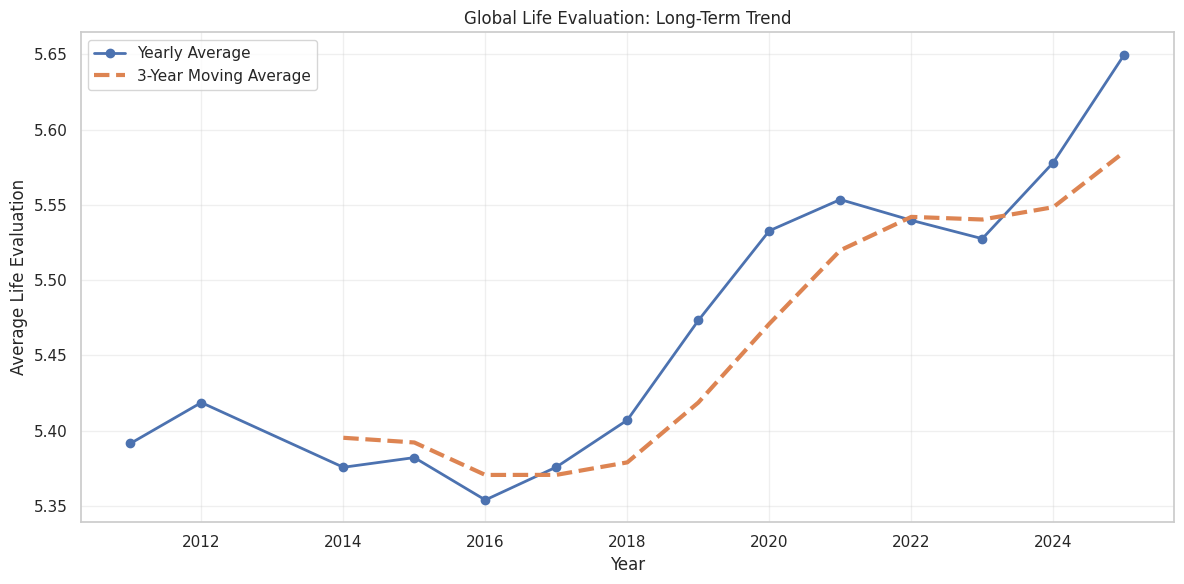

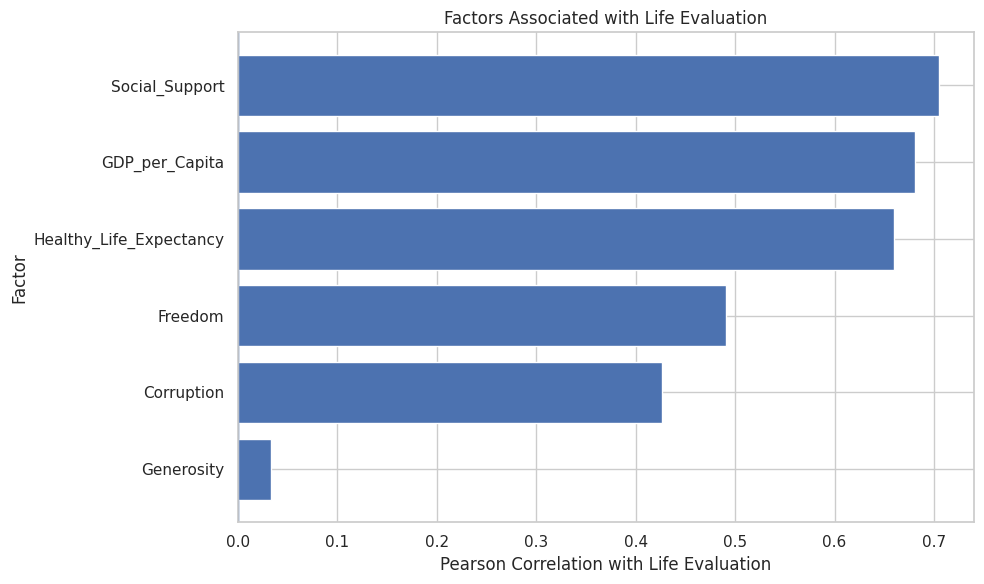

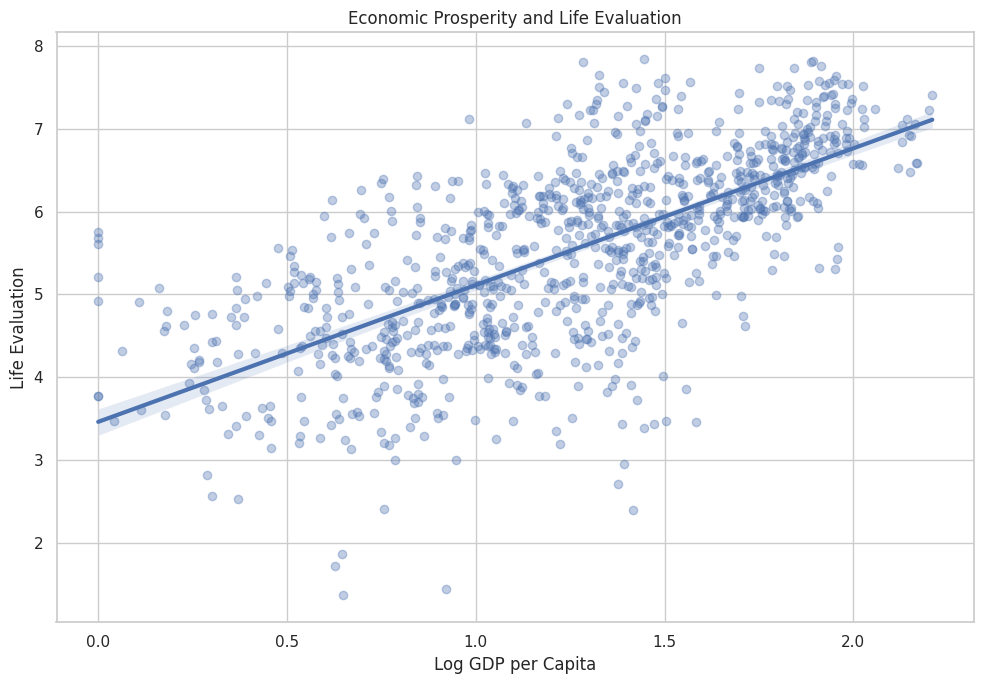

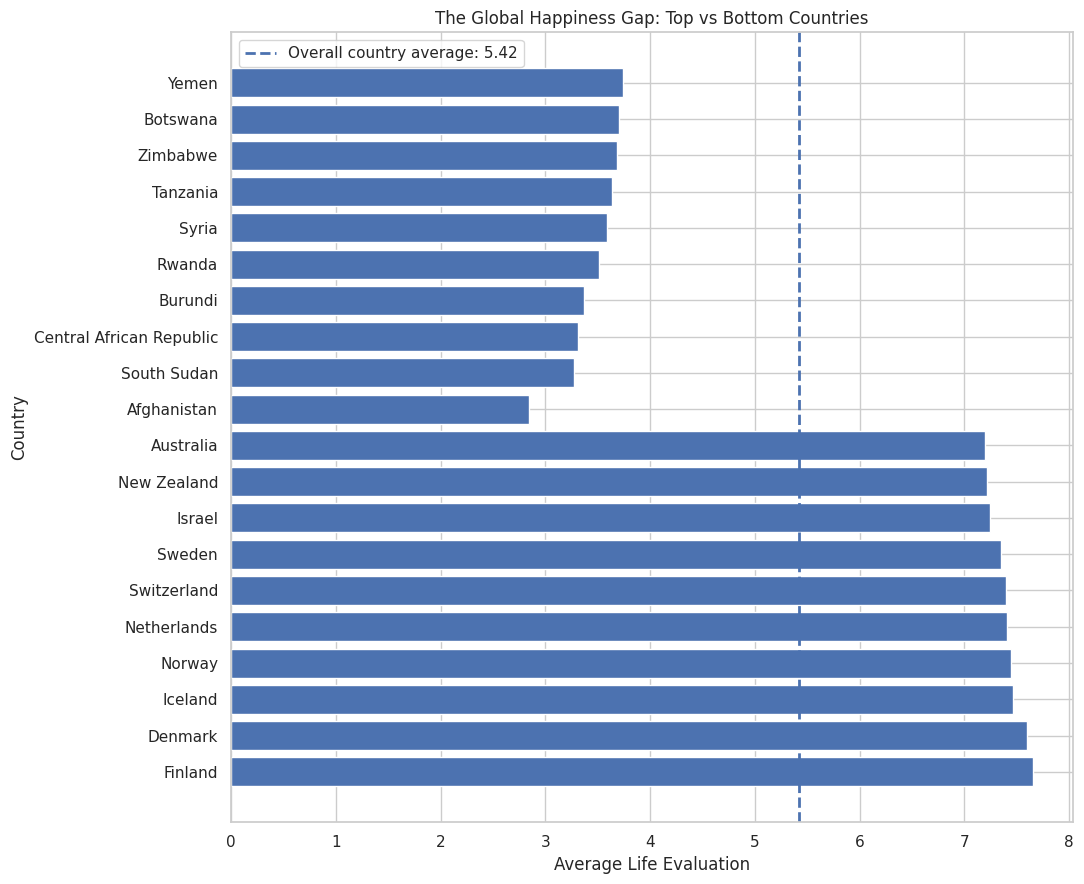

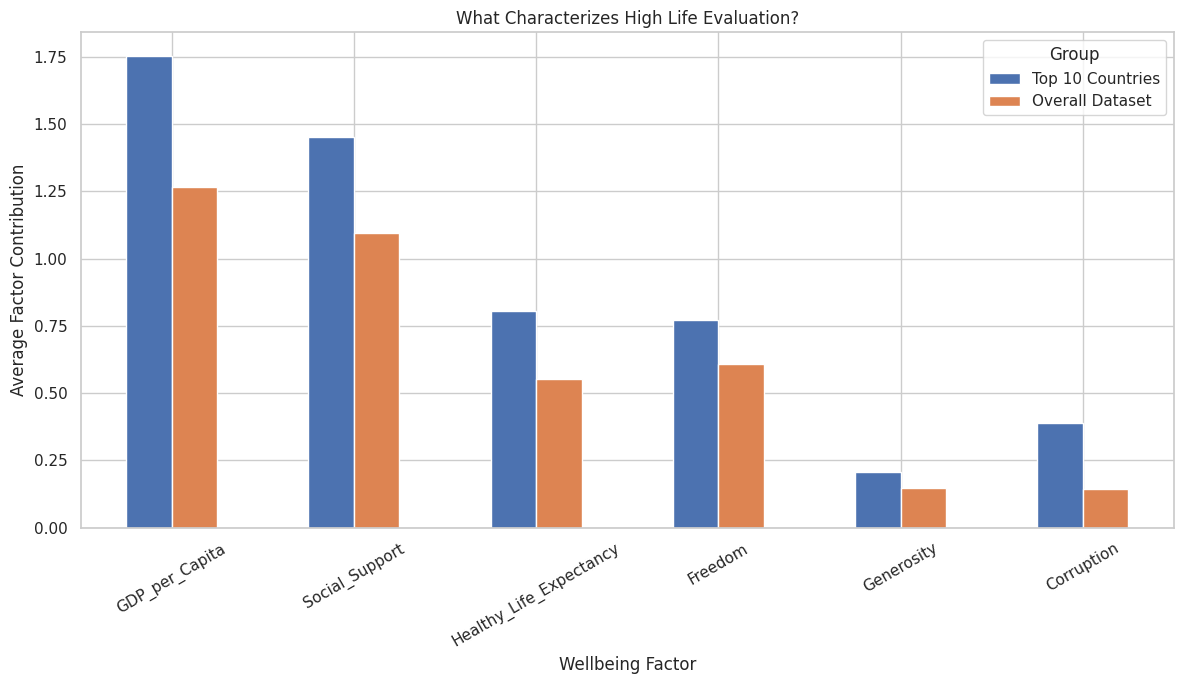

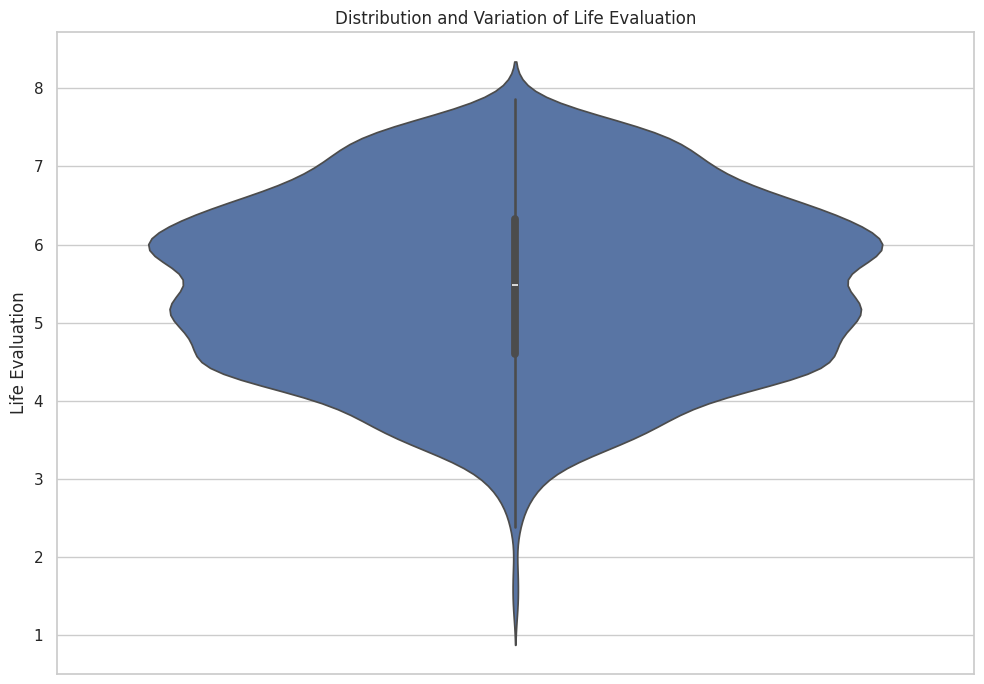

All remaining visualizations have been saved successfully.


In [18]:
import os

os.makedirs("week2_visualizations", exist_ok=True)

# 2. Happiness Trend
plt.figure(figsize=(12, 6))

plt.plot(
    yearly_happiness["Year"],
    yearly_happiness["Life_Evaluation"],
    marker="o",
    linewidth=2,
    label="Yearly Average"
)

plt.plot(
    yearly_happiness["Year"],
    yearly_happiness["3Y_Moving_Average"],
    linestyle="--",
    linewidth=3,
    label="3-Year Moving Average"
)

plt.title("Global Life Evaluation: Long-Term Trend")
plt.xlabel("Year")
plt.ylabel("Average Life Evaluation")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    "week2_visualizations/02_happiness_trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# 3. Factor Correlations
plt.figure(figsize=(10, 6))

plt.barh(
    correlations.index,
    correlations.values
)

plt.axvline(0, linewidth=1)

plt.title("Factors Associated with Life Evaluation")
plt.xlabel("Pearson Correlation with Life Evaluation")
plt.ylabel("Factor")

plt.tight_layout()

plt.savefig(
    "week2_visualizations/03_factor_correlations.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# 4. GDP vs Life Evaluation
plt.figure(figsize=(10, 7))

sns.regplot(
    data=df_factor,
    x="GDP_per_Capita",
    y="Life_Evaluation",
    scatter_kws={"alpha": 0.35},
    line_kws={"linewidth": 3}
)

plt.title("Economic Prosperity and Life Evaluation")
plt.xlabel("Log GDP per Capita")
plt.ylabel("Life Evaluation")

plt.tight_layout()

plt.savefig(
    "week2_visualizations/04_gdp_relationship.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# 5. Top vs Bottom Countries
plt.figure(figsize=(11, 9))

plt.barh(
    comparison.index,
    comparison.values
)

plt.axvline(
    country_happiness.mean(),
    linestyle="--",
    linewidth=2,
    label=f"Overall country average: {country_happiness.mean():.2f}"
)

plt.title("The Global Happiness Gap: Top vs Bottom Countries")
plt.xlabel("Average Life Evaluation")
plt.ylabel("Country")
plt.legend()

plt.tight_layout()

plt.savefig(
    "week2_visualizations/05_happiness_gap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# 6. High-Happiness Country Profile
ax = comparison_factors.plot(
    kind="bar",
    figsize=(12, 7)
)

plt.title("What Characterizes High Life Evaluation?")
plt.xlabel("Wellbeing Factor")
plt.ylabel("Average Factor Contribution")
plt.xticks(rotation=30)
plt.legend(title="Group")

plt.tight_layout()

plt.savefig(
    "week2_visualizations/06_high_happiness_profile.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# 7. Distribution of Life Evaluation
plt.figure(figsize=(10, 7))

sns.violinplot(
    data=df,
    y="Life_Evaluation",
    inner="box"
)

plt.title("Distribution and Variation of Life Evaluation")
plt.ylabel("Life Evaluation")

plt.tight_layout()

plt.savefig(
    "week2_visualizations/07_life_evaluation_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


print("All remaining visualizations have been saved successfully.")